# Redes Neuronales y Descenso de Gradiente

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

In [1]:
#!sudo apt-get update
# Instala LaTeX (texlive) para que matplotlib pueda renderizar texto con usetex=True
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import matplotlib.pyplot as plt  # graficas

import matplotlib.colors as mcolors  # utilidades de color (no se usa directamente aqui)

import numpy as np  # arreglos y algebra lineal en CPU (sin autodiff)

# Configuracion global de estilo para todas las figuras del notebook
plt.rcParams.update({
    "text.usetex": True,            # usar LaTeX real para renderizar texto/formulas
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estetica
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

# --- JAX ---
import jax                         # libreria de autodiff + compilacion 
import jax.numpy as jnp            # tipo NumPy, pero con arreglos que JAX puede diferenciar
from jax import grad, jit, vmap    # grad: deriva funciones; jit: compila para acelerar; vmap: vectoriza sin loops explicitos

print('Configuracion OK')

Configuracion OK


## El hilo del curso

En todos los métodos anteriores buscamos una aproximación de la forma

$$\hat{f}(x) = \sum_{i=1}^n c_i\,\phi_i(x)$$

donde las **bases** $\phi_i$ estaban fijas (monomios, splines, Bézier) y solo optimizábamos los **coeficientes** $c_i$.

En una red neuronal, los $\phi_i$ **también dependen de parámetros** que se aprenden de los datos. El precio: necesitamos optimizar una función de pérdida $\mathcal{L}(\theta)$ sobre todos los parámetros $\theta$ a la vez.

## 1. La función de pérdida como mínimos cuadrados

Dado un conjunto de datos $\{(x_i, y_i)\}_{i=1}^N$ con $y_i = f(x_i)$, definimos la pérdida cuadrática:

$${L}(\theta) = \frac{1}{N}\sum_{i=1}^N \bigl(y_i - \hat{f}(x_i;\theta)\bigr)^2 = \frac{1}{N}\|y - \hat{y}(\theta)\|^2$$

Para una **red lineal** $\hat{f}(x;\theta) = \theta^\top \phi(x)$ esto es exactamente mínimos cuadrados:

$${L}(\theta) = \frac{1}{N}\|y - A\theta\|^2, \qquad A_{ij} = \phi_j(x_i)$$

con mínimo en $\theta^* = (A^\top A)^{-1} A^\top y$ (ecuaciones normales).

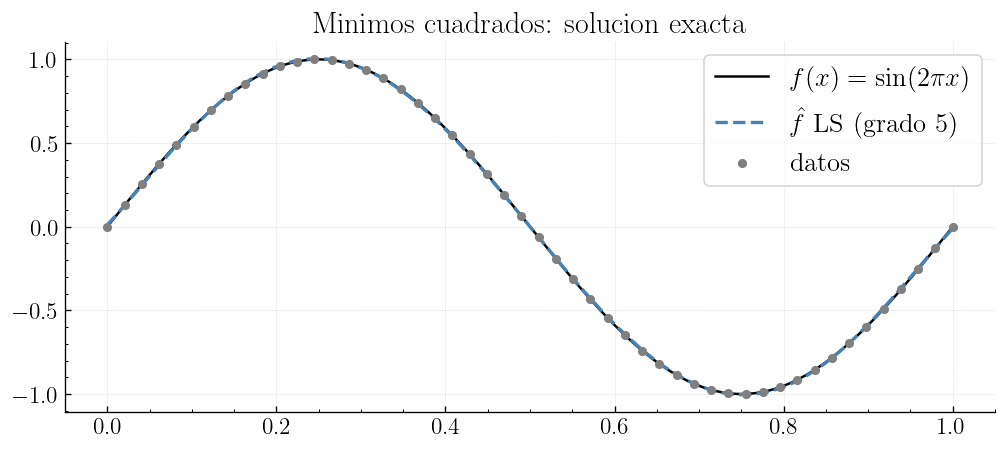

Loss minimos cuadrados: 2.28e-05


In [2]:
# Funcion objetivo: f(x) = sin(2*pi*x)
np.random.seed(123)            # fija la semilla aleatoria para reproducibilidad
N = 50                         # numero de puntos de datos
xs = np.linspace(0, 1, N)      # N puntos equiespaciados en [0, 1]
ys = np.sin(2 * np.pi * xs)    # valores de la funcion objetivo en esos puntos

# Red lineal: phi_j(x) = x^j, j = 0,...,p-1
p = 6                                     # numero de bases (grado p-1)
A = np.vander(xs, p, increasing=True)     # A[i,j] = xs[i]^j  -> matriz de diseno (N x p)

# Minimos cuadrados: solucion exacta
theta_ls, _, _, _ = np.linalg.lstsq(A, ys, rcond=None)  # resuelve A theta ~ ys via SVD (ecuaciones normales)

x_cont = np.linspace(0, 1, 300)              # malla fina para graficar la curva continua
A_cont = np.vander(x_cont, p, increasing=True)  # matriz de diseno evaluada en la malla fina
y_ls   = A_cont @ theta_ls                    # prediccion de la red lineal con los coeficientes optimos

plt.figure(figsize=(10, 4))
plt.plot(x_cont, np.sin(2 * np.pi * x_cont), 'k-', lw=1.5, label=r'$f(x) = \sin(2\pi x)$')  # funcion real
plt.plot(x_cont, y_ls, '--', color='steelblue', lw=2,
         label=rf'$\hat{{f}}$ LS (grado {p-1})')   # aproximacion por minimos cuadrados
plt.scatter(xs, ys, s=20, color='gray', zorder=5, label='datos')  # puntos de entrenamiento
plt.legend()
plt.title('Minimos cuadrados: solucion exacta')
plt.grid(True)
plt.show()

loss_ls = np.mean((ys - A @ theta_ls)**2)  # error cuadratico medio de la solucion exacta (referencia)
print(f'Loss minimos cuadrados: {loss_ls:.2e}')

## 2. Descenso de gradiente sobre la pérdida cuadrática

En lugar de resolver las ecuaciones normales, usamos el **descenso de gradiente**:

$$\theta_{k+1} = \theta_k - \eta\,\nabla_\theta{L}(\theta_k)$$

Para la pérdida cuadrática lineal el gradiente es:

$$\nabla_\theta{L}(\theta) = \frac{2}{N}A^\top(A\theta - y)$$

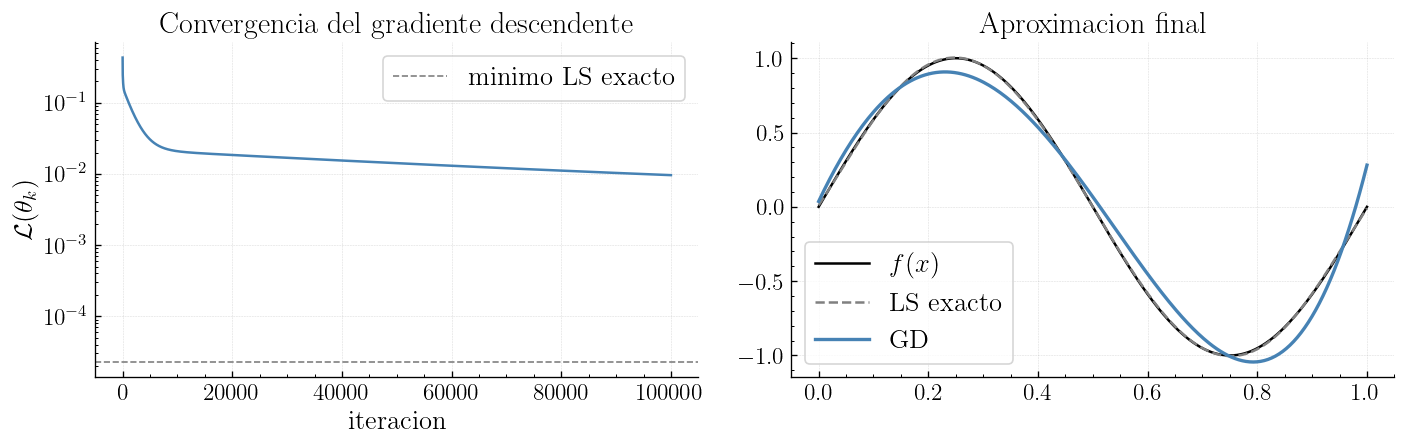

Loss GD: 9.64e-03  |  Loss LS exacto: 2.28e-05


In [11]:
# Gradiente exacto de L(theta) = (1/N) ||y - A theta||^2
def grad_loss_lineal(theta, A, y):
    residuo = A @ theta - y                # vector de errores (A theta - y)
    return (2 / len(y)) * A.T @ residuo     # formula cerrada del gradiente (calculado a mano, sin JAX)

eta =2e-1   # tasa de aprendizaje (paso del descenso de gradiente)

# Descenso de gradiente
theta = np.zeros(p)        # inicializa los coeficientes en cero
n_iter = 100000             # numero de iteraciones de descenso de gradiente
historico = []              # guarda la perdida en cada iteracion para graficar la convergencia

for _ in range(n_iter):
    theta = theta - eta * grad_loss_lineal(theta, A, ys)  # paso de actualizacion: theta <- theta - eta * grad
    historico.append(np.mean((ys - A @ theta)**2))         # registra la perdida actual

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(historico, color='steelblue', lw=1.5)                          # perdida en escala log vs iteracion
axes[0].axhline(loss_ls, color='gray', ls='--', lw=1, label='minimo LS exacto')  # referencia: minimo exacto
axes[0].set_xlabel('iteracion'); axes[0].set_ylabel(r'$\mathcal{L}(\theta_k)$')
axes[0].set_title('Convergencia del gradiente descendente')
axes[0].legend()
axes[0].grid(True)

y_gd = A_cont @ theta   # prediccion final de la red lineal entrenada por descenso de gradiente
axes[1].plot(x_cont, np.sin(2 * np.pi * x_cont), 'k-', lw=1.5, label=r'$f(x)$')          # funcion real
axes[1].plot(x_cont, y_ls, '--', color='gray', lw=1.5, label='LS exacto')                # solucion exacta
axes[1].plot(x_cont, y_gd, '-', color='steelblue', lw=2, label='GD')                     # solucion por GD
#axes[1].scatter(xs, ys, s=15, color='gray', zorder=5)
axes[1].legend(); axes[1].set_title('Aproximacion final')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f'Loss GD: {historico[-1]:.2e}  |  Loss LS exacto: {loss_ls:.2e}')

## 3. Red neuronal de una capa oculta

Ahora $\hat{f}$ es **no lineal** en $\theta$:

$$\hat{f}(x;\theta) = W_2\,\sigma(W_1 x + \mathbf{b}_1) + b_2$$

con $\sigma(z) = \tanh(z)$. Los parámetros son $\theta = \{W_1, \mathbf{b}_1, W_2, b_2\}$.

La pérdida ya no es convexa, pero el gradiente descendente sigue funcionando localmente.
JAX calcula $\nabla_\theta {L}$ automáticamente via backpropagation.

In [4]:
# Arquitectura: 1 -> m -> 1
m = 20  # neuronas ocultas

def init_params(m, key):
    # jax.random.split: divide una "key" (semilla) de JAX en varias keys independientes.
    # JAX no tiene estado aleatorio global como numpy: cada llamada aleatoria necesita su propia key.
    k1, k2, k3, k4 = jax.random.split(key, 4)
    return {
        'W1': jax.random.normal(k1, (m, 1)) * 0.1,  # pesos capa 1: jax.random.normal genera m x 1 valores ~ N(0,1)
        'b1': jnp.zeros((m,)),                       # sesgo capa 1, inicializado en cero (jnp.zeros = np.zeros pero diferenciable/compilable)
        'W2': jax.random.normal(k3, (1, m)) * 0.1,  # pesos capa 2 (salida): 1 x m
        'b2': jnp.zeros((1,)),                       # sesgo capa 2
    }

def red(params, x):
    # Forward pass
    h = jnp.tanh(params['W1'] @ jnp.array([x]) + params['b1'])  # capa oculta: tanh(W1 x + b1), forma (m,)
    return (params['W2'] @ h + params['b2'])[0]                  # capa de salida: W2 h + b2, escalar

def loss(params, xs, ys):
    # vmap("vectorized map"): aplica `red` a cada x de xs SIN escribir un loop explicito.
    # JAX traduce esto en una operacion vectorizada/batched, mucho mas eficiente que un for.
    y_hat = vmap(lambda x: red(params, x))(xs)
    return jnp.mean((ys - y_hat) ** 2)   # error cuadratico medio (MSE)

# Verificar forward pass
semilla = jax.random.PRNGKey(123)       # crea la semilla raiz del generador aleatorio de JAX
params = init_params(m, semilla)        # inicializa los parametros de la red
xs_jax = jnp.array(xs)              # convierte los datos de numpy a arreglos de JAX (jnp)
ys_jax = jnp.array(ys)

print(f'Loss inicial: {loss(params, xs_jax, ys_jax):.4f}')
# jax.tree_util.tree_leaves: recorre el "pytree" (el diccionario de parametros, que puede anidar
# dicts/listas/tuplas) y devuelve una lista plana con todos los arreglos hoja, para poder sumarlos.
print(f'Parametros totales: {sum(v.size for v in jax.tree_util.tree_leaves(params))}')

Loss inicial: 0.4928
Parametros totales: 61


## 4. Backpropagation con JAX

`jax.grad(loss)` calcula $\nabla_\theta {L}$ exactamente via autodiff en modo reverso.
Una llamada a `grad` corresponde a una pasada backward sobre el grafo computacional de `loss`.

In [5]:
# jax.grad(loss): construye una nueva funcion que calcula el gradiente de `loss` respecto a su
# primer argumento (params), usando diferenciacion automatica en modo reverso (backpropagation).
# jit(...): compila esa funcion la primera vez que se llama, para que las llamadas
# siguientes corran mucho mas rapido (evita reinterpretar Python en cada iteracion).
grad_loss = jit(grad(loss))  # backward pass compilado

# Verificar que los gradientes tienen la misma forma que los parametros
grads = grad_loss(params, xs_jax, ys_jax)   # grads es un dict con la misma estructura que params,
                                              # pero cada hoja es dL/dParametro
for k in params:
    print(f'grad[{k}]: shape {grads[k].shape},  norma {jnp.linalg.norm(grads[k]):.4f}')

grad[W1]: shape (20, 1),  norma 0.1587
grad[b1]: shape (20,),  norma 0.0039
grad[W2]: shape (1, 20),  norma 0.1272
grad[b2]: shape (1,),  norma 0.0090


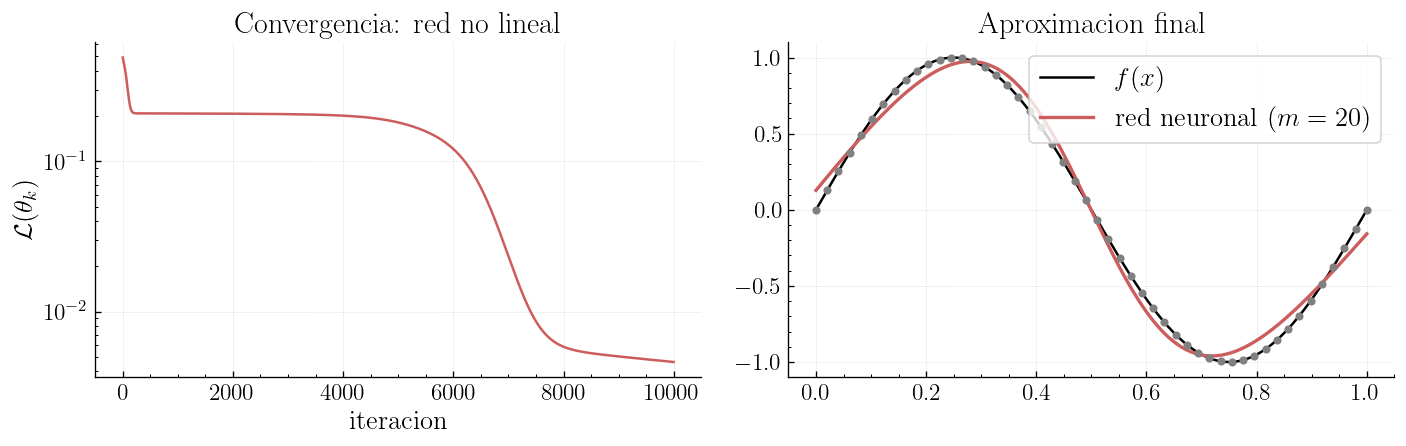

Loss final: 4.62e-03


In [6]:
# Descenso de gradiente sobre la red no lineal
eta = 0.05            # tasa de aprendizaje
n_iter = 10000        # numero de iteraciones de entrenamiento
historico_nn = []     # guarda la perdida en cada iteracion

params = init_params(m, semilla)   # reinicializa los parametros antes de entrenar

for k in range(n_iter):
    grads = grad_loss(params, xs_jax, ys_jax)   # gradiente actual via autodiff (jit + grad)
    # Actualizar todos los parametros: theta <- theta - eta * grad
    # jax.tree_util.tree_map: aplica la funcion lambda a cada par de hojas (p de params, g de grads)
    # recorriendo el pytree completo, sin necesidad de iterar manualmente sobre cada parte del dict.
    params = jax.tree_util.tree_map(lambda p, g: p - eta * g, params, grads)
    historico_nn.append(float(loss(params, xs_jax, ys_jax)))  # registra la perdida (float() saca el valor de JAX a Python)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(historico_nn, color='indianred', lw=1.5)   # convergencia de la perdida en escala log
axes[0].set_xlabel('iteracion'); axes[0].set_ylabel(r'$\mathcal{L}(\theta_k)$')
axes[0].set_title('Convergencia: red no lineal')
axes[0].grid(True)

x_cont_jax = jnp.linspace(0, 1, 300)             # malla fina en JAX para evaluar la red entrenada
y_nn = vmap(lambda x: red(params, x))(x_cont_jax)  # evalua la red en toda la malla sin loop (vmap)

axes[1].plot(x_cont, np.sin(2 * np.pi * x_cont), 'k-', lw=1.5, label=r'$f(x)$')   # funcion real
axes[1].plot(np.array(x_cont_jax), np.array(y_nn), '-', color='indianred', lw=2,
             label=f'red neuronal ($m={m}$)')   # prediccion de la red (convertida a numpy para graficar)
axes[1].scatter(xs, ys, s=15, color='gray', zorder=5)
axes[1].legend(); axes[1].set_title('Aproximacion final')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f'Loss final: {historico_nn[-1]:.2e}')

### Ejercicio

Completen la siguiente celda para comparar redes con $m \in \{2, 5, 20, 50\}$ neuronas.
Para cada una, entrenen 2000 iteraciones y grafiquen la pérdida final vs $m$.

¿A partir de qué $m$ la red aproxima bien $\sin(2\pi x)$?

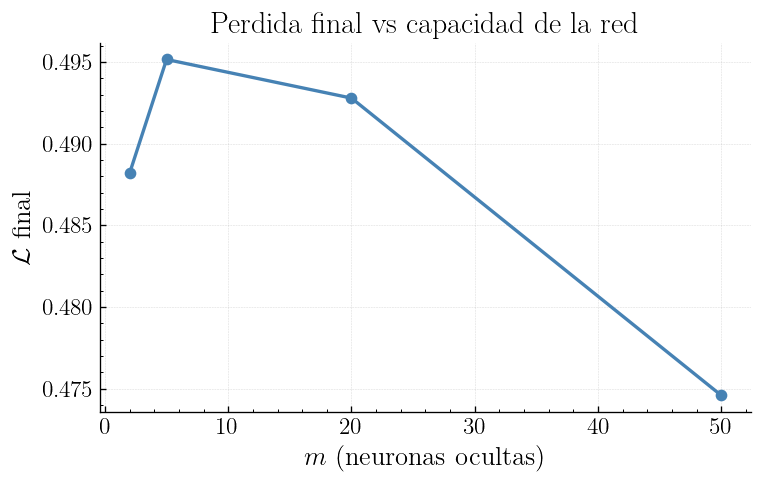

In [12]:
ms = [2, 5, 20, 50]   # tamanos de capa oculta a comparar
losses_finales = []    # perdida final obtenida para cada m

for m_i in ms:
    params_i = init_params(m_i, semilla)   # nuevos parametros aleatorios para este tamano de red
    grad_loss_i = jit(grad(loss))      # gradiente compilado (igual que grad_loss, redefinido aqui)

    for _ in range(2000):
        # completar: actualizar params_i con gradiente descendente
        pass

    losses_finales.append(float(loss(params_i, xs_jax, ys_jax)))  # perdida final sin entrenar (placeholder)

plt.figure(figsize=(7, 4))
plt.plot(ms, losses_finales, 'o-', color='steelblue', lw=2)
plt.xlabel(r'$m$ (neuronas ocultas)')
plt.ylabel(r'$\mathcal{L}$ final')
plt.title('Perdida final vs capacidad de la red')
plt.grid(True)
plt.show()


## Ejercicio  — Una red que aproxima $\sin(1/x)$

La función $\sin(1/x)$ es un caso difícil: cerca de $x=0$ oscila **infinitamente rápido**.
Es una buena prueba de estrés para una red, porque obliga a las bases $\phi_i(x)=\sigma(w_i x + b_i)$
a concentrarse donde la función cambia más.

En vez de mirar solo la curva final, vamos a **ver cómo evoluciona el entrenamiento en el tiempo**:
guardaremos la predicción de la red cada cierto número de iteraciones y la graficaremos.

**Tareas**
1. Generen datos de $g(x)=\sin(1/x)$ en $x\in[0.05,\,1]$ (evitamos $x=0$).
2. Entrenen la red de una capa oculta del notebook (reutilicen `init_params`, `loss`, `grad_loss`).
3. Cada `snap_every` iteraciones, guarden la predicción actual en una lista.
4. Grafiquen varias instantáneas superpuestas para ver la convergencia.

¿En qué región del dominio aprende primero la red? ¿Por qué le cuesta la zona cercana a $x=0$?

In [ ]:
# Datos: g(x) = sin(1/x) en [0.05, 1]
np.random.seed(0)
N = 200
xs_e3 = np.linspace(0.05, 1.0, N)        # evitamos x=0 (oscilacion infinita)
ys_e3 = np.sin(1.0 / xs_e3)              # funcion objetivo

xs_j = jnp.asarray(xs_e3)
ys_j = jnp.asarray(ys_e3)

m = 64                                    # mas neuronas: la funcion es exigente
params = init_params(m, semilla)          # reutiliza el inicializador del notebook
grad_loss = jit(grad(loss))

eta = 0.01
n_iter = 20000
snap_every = 2000                         # guardar prediccion cada 2000 iteraciones
snapshots = []                            # (iteracion, prediccion) para graficar la evolucion

for k in range(n_iter):
    grads = grad_loss(params, xs_j, ys_j)
    params = jax.tree_util.tree_map(lambda p, g: p - eta * g, params, grads)
    if k % snap_every == 0:
        # completar: guardar (k, prediccion actual) en snapshots
        # pred = ...                      # evaluar la red en xs_j (ver funcion forward del notebook)
        # snapshots.append((k, np.asarray(pred)))
        pass

# Visualizar la evolucion del entrenamiento en el tiempo
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(xs_e3, ys_e3, color="lightgray", lw=4, label=r"$\sin(1/x)$")
colores = plt.cm.viridis(np.linspace(0, 1, len(snapshots)))
for (it, pred), c in zip(snapshots, colores):
    ax.plot(xs_e3, pred, color=c, lw=1.5, label=f"iter {it}")
ax.set_xlabel("$x$"); ax.set_ylabel("$g(x)$")
ax.legend(fontsize=9, ncol=2); ax.grid(True)
plt.show()

## Ejercicio — Una red profunda (más de una capa oculta)

Hasta ahora usamos **una** capa oculta. El teorema de aproximación universal garantiza que
con suficientes neuronas eso basta — pero a un costo: a veces se necesitan *muchísimas*.
En la práctica, **apilar capas** suele lograr el mismo error con muchas menos neuronas por capa.

Una red de dos capas ocultas es:
$$\hat{f}(x) = W_3\,\sigma\bigl(W_2\,\sigma(W_1 x + \mathbf{b}_1) + \mathbf{b}_2\bigr) + b_3.$$

Cada capa toma como entrada las **bases aprendidas** de la capa anterior: la red construye
bases de bases. Esto es composición de funciones, y `jax.grad` propaga el gradiente a través
de todas las capas automáticamente (backpropagation = regla de la cadena).

**Tareas**
1. Completen `init_params_deep` para una arquitectura $1 \to m_1 \to m_2 \to 1$.
2. Completen el `forward_deep` (dos aplicaciones de $\tanh$).
3. Entrenen sobre $\sin(2\pi x)$ o sobre $\sin(1/x)$ del ejercicio anterior.
4. Comparen la pérdida final contra la red de **una** capa con el mismo número total de neuronas.

¿La red profunda gana con el mismo presupuesto de neuronas? ¿En cuál función la diferencia es mayor?

In [ ]:
# Arquitectura profunda: 1 -> m1 -> m2 -> 1
def init_params_deep(m1, m2, key):
    k1, k2, k3, k4, k5, k6 = jax.random.split(key, 6)
    return {
        'W1': jax.random.normal(k1, (m1, 1)) * 0.1, 'b1': jnp.zeros((m1,)),
        'W2': jax.random.normal(k2, (m2, m1)) * 0.1, 'b2': jnp.zeros((m2,)),
        'W3': jax.random.normal(k3, (1, m2)) * 0.1, 'b3': jnp.zeros((1,)),
    }

def forward_deep(params, x):
    # x: (N,) -> columna (N,1) -> capas -> (N,)
    h = x.reshape(-1, 1)                                   # (N,1)
    h = jnp.tanh(h @ params['W1'].T + params['b1'])       # capa 1: (N,m1)
    # completar: capa 2 con W2, b2 y tanh
    # h = ...                                              # (N,m2)
    out = h @ params['W3'].T + params['b3']               # capa salida: (N,1)
    return out.ravel()                                     # (N,)

def loss_deep(params, x, y):
    return jnp.mean((forward_deep(params, x) - y) ** 2)

grad_loss_deep = jit(grad(loss_deep))

m1, m2 = 16, 16
params = init_params_deep(m1, m2, semilla)
eta, n_iter = 0.02, 15000
hist_deep = []
for k in range(n_iter):
    grads = grad_loss_deep(params, xs_j, ys_j)
    params = jax.tree_util.tree_map(lambda p, g: p - eta * g, params, grads)
    hist_deep.append(float(loss_deep(params, xs_j, ys_j)))

print("pérdida final (red profunda):", hist_deep[-1])

plt.figure(figsize=(7, 4))
plt.semilogy(hist_deep, color="teal")
plt.xlabel("iteración"); plt.ylabel(r"$\mathcal{L}$")
plt.title("Convergencia red profunda")
plt.grid(True)
plt.show()